# 🚗 Automobile Imports Price Prediction
## Capstone Machine Learning Project

**Objective:** Predict the price of automobiles based on various features such as engine size, horsepower, fuel type, body style, and more.

**Dataset:** UCI Machine Learning Repository — Automobile Dataset (1985 Ward's Automotive Yearbook)

**Workflow:**
1. Data Loading & Understanding
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Encoding
5. Model Training (8 Regression Models)
6. Model Evaluation & Comparison
7. Hyperparameter Tuning
8. Final Model & Prediction

---
## Step 1: Import Libraries

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save model
import joblib
import os

print('✅ All libraries imported successfully!')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}')

✅ All libraries imported successfully!
NumPy: 1.26.4, Pandas: 2.1.4


---
## Step 2: Load Dataset

In [4]:
# Column names from UCI documentation
columns = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
    'num_doors', 'body_style', 'drive_wheels', 'engine_location',
    'wheel_base', 'length', 'width', 'height', 'curb_weight',
    'engine_type', 'num_cylinders', 'engine_size', 'fuel_system',
    'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm',
    'city_mpg', 'highway_mpg', 'price'
]

# Load from UCI repository or use a local fallback file if the network is unavailable
from pathlib import Path

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'

fallback_candidates = [
    Path.cwd() / 'automobile_fallback.csv',
    Path.cwd().parent / 'Automoblie' / 'automobile_fallback.csv',
    Path(r'C:/Users/HP/Desktop/Automoblie/automobile_fallback.csv')
]

try:
    df = pd.read_csv(url, names=columns, na_values='?')
    print('Loaded dataset from UCI repository.')
except Exception as e:
    print(f'Unable to load remote dataset: {e}')
    fallback_path = None
    for candidate in fallback_candidates:
        if candidate.exists():
            fallback_path = candidate
            break

    if fallback_path is None:
        raise FileNotFoundError('No fallback dataset was found. Please place automobile_fallback.csv in the workspace folder.')

    df = pd.read_csv(fallback_path, names=columns, na_values='?')
    print(f'Loaded fallback dataset from: {fallback_path}')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Loaded dataset from UCI repository.
Dataset Shape: (205, 26)
Rows: 205, Columns: 26


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [5]:
# Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          203 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    object 
 16  engine_size        205 non

In [6]:
# Statistical Summary
df.describe()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


---
## Step 3: Data Cleaning & Preprocessing

In [7]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                   Missing Count  Missing %
normalized_losses             41      20.00
num_doors                      2       0.98
bore                           4       1.95
stroke                         4       1.95
horsepower                     2       0.98
peak_rpm                       2       0.98
price                          4       1.95


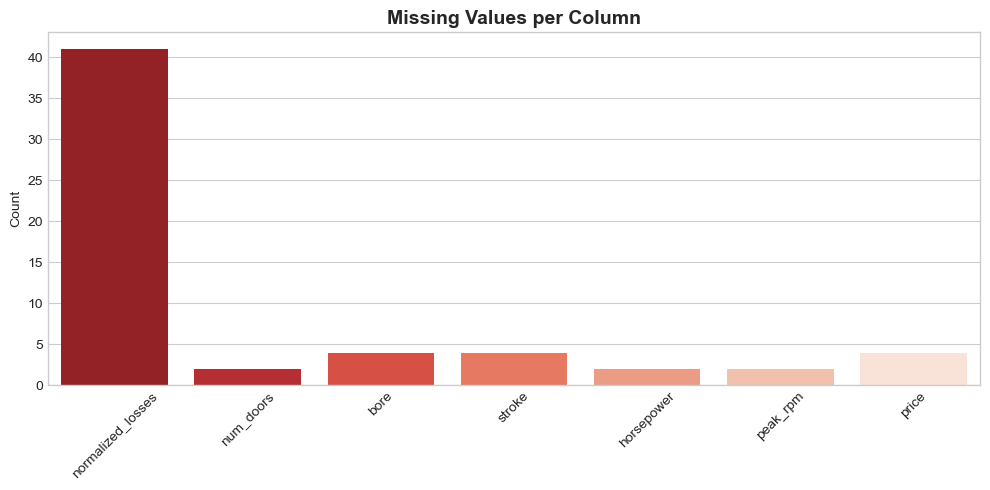

In [9]:
# Visualize missing values
from pathlib import Path

output_dir = Path.cwd() / 'outputs'
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 5))
missing_data = df.isnull().sum()[df.isnull().sum() > 0]
sns.barplot(x=missing_data.index, y=missing_data.values, palette='Reds_r')
plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(output_dir / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Drop rows where target variable 'price' is missing
df.dropna(subset=['price'], inplace=True)
print(f'Rows after dropping missing price: {len(df)}')

# Convert target to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('✅ Missing values handled!')

Rows after dropping missing price: 201
Missing values remaining: 0
✅ Missing values handled!


In [11]:
# Fix 'num_doors' and 'num_cylinders' — convert text to numbers
door_map = {'two': 2, 'four': 4}
cylinder_map = {'two': 2, 'three': 3, 'four': 4, 'five': 5,
                'six': 6, 'eight': 8, 'twelve': 12}

df['num_doors'] = df['num_doors'].map(door_map)
df['num_cylinders'] = df['num_cylinders'].map(cylinder_map)

print('num_doors unique:', df['num_doors'].unique())
print('num_cylinders unique:', df['num_cylinders'].unique())

num_doors unique: [2 4]
num_cylinders unique: [ 4  6  5  3 12  2  8]


In [12]:
# Check and remove duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Dataset shape after cleaning: {df.shape}')

Duplicate rows: 0
Dataset shape after cleaning: (201, 26)


---
## Step 4: Exploratory Data Analysis (EDA)

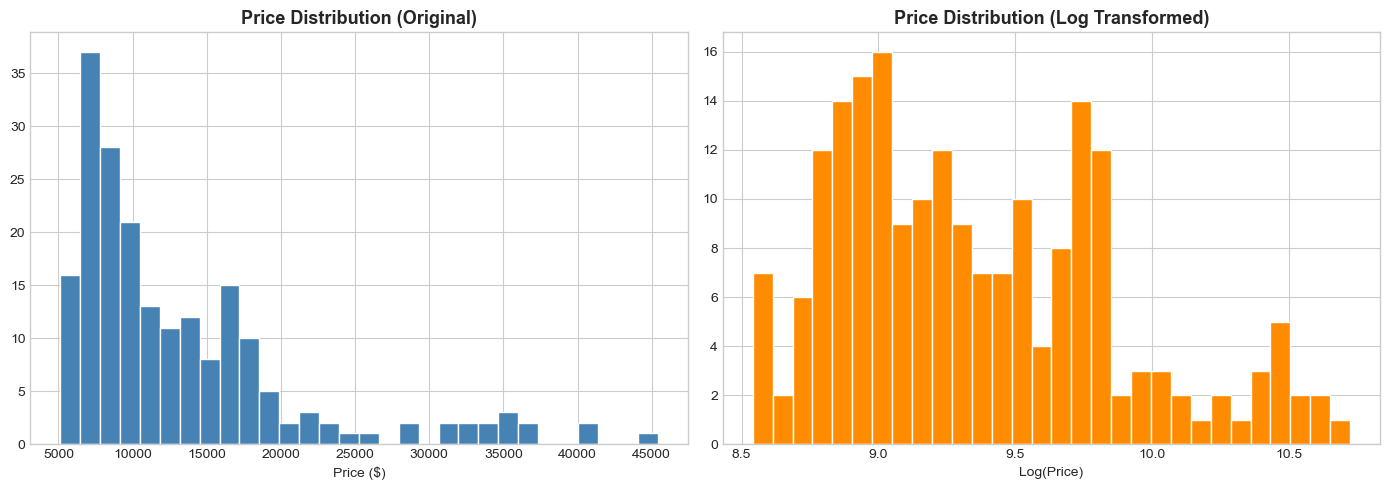

Price - Mean: $13,207, Median: $10,295


In [15]:
# Target Variable Distribution
from pathlib import Path

output_dir = Path.cwd() / 'outputs'
output_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Original)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(df['price']), bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Price Distribution (Log Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.savefig(output_dir / 'price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Price - Mean: ${df["price"].mean():,.0f}, Median: ${df["price"].median():,.0f}')

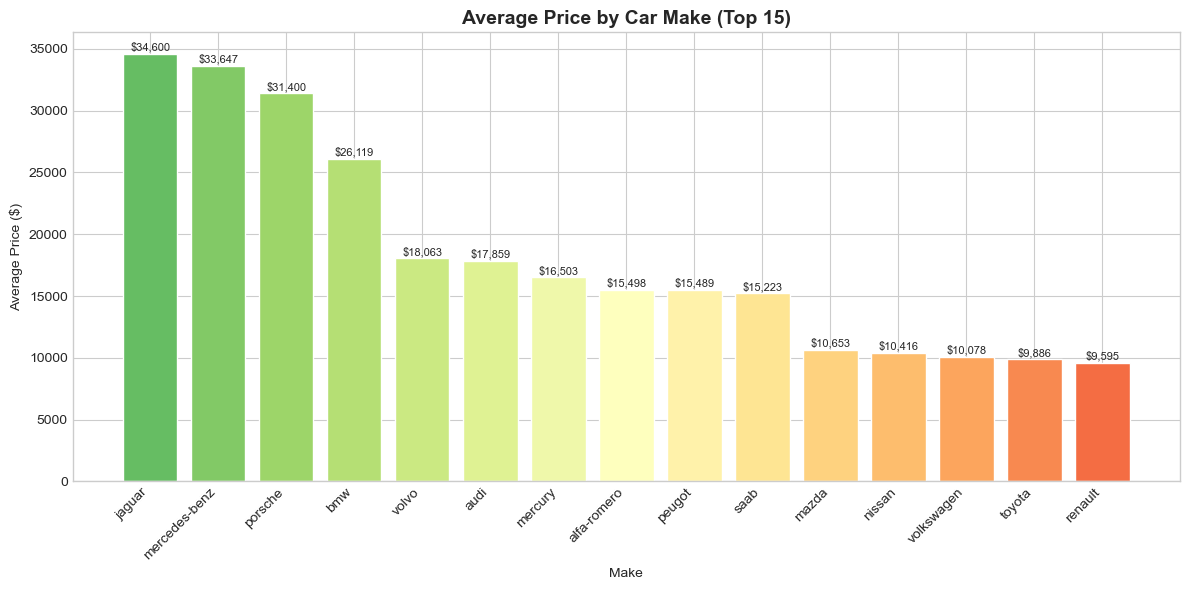

In [23]:
# Price by Car Make (Top 15)
top_makes = df.groupby('make')['price'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(top_makes)))
bars = plt.bar(top_makes.index, top_makes.values, color=colors, edgecolor='white')
plt.title('Average Price by Car Make (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Make')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, top_makes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'${val:,.0f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / 'price_by_make.png', dpi=150, bbox_inches='tight')
plt.show()

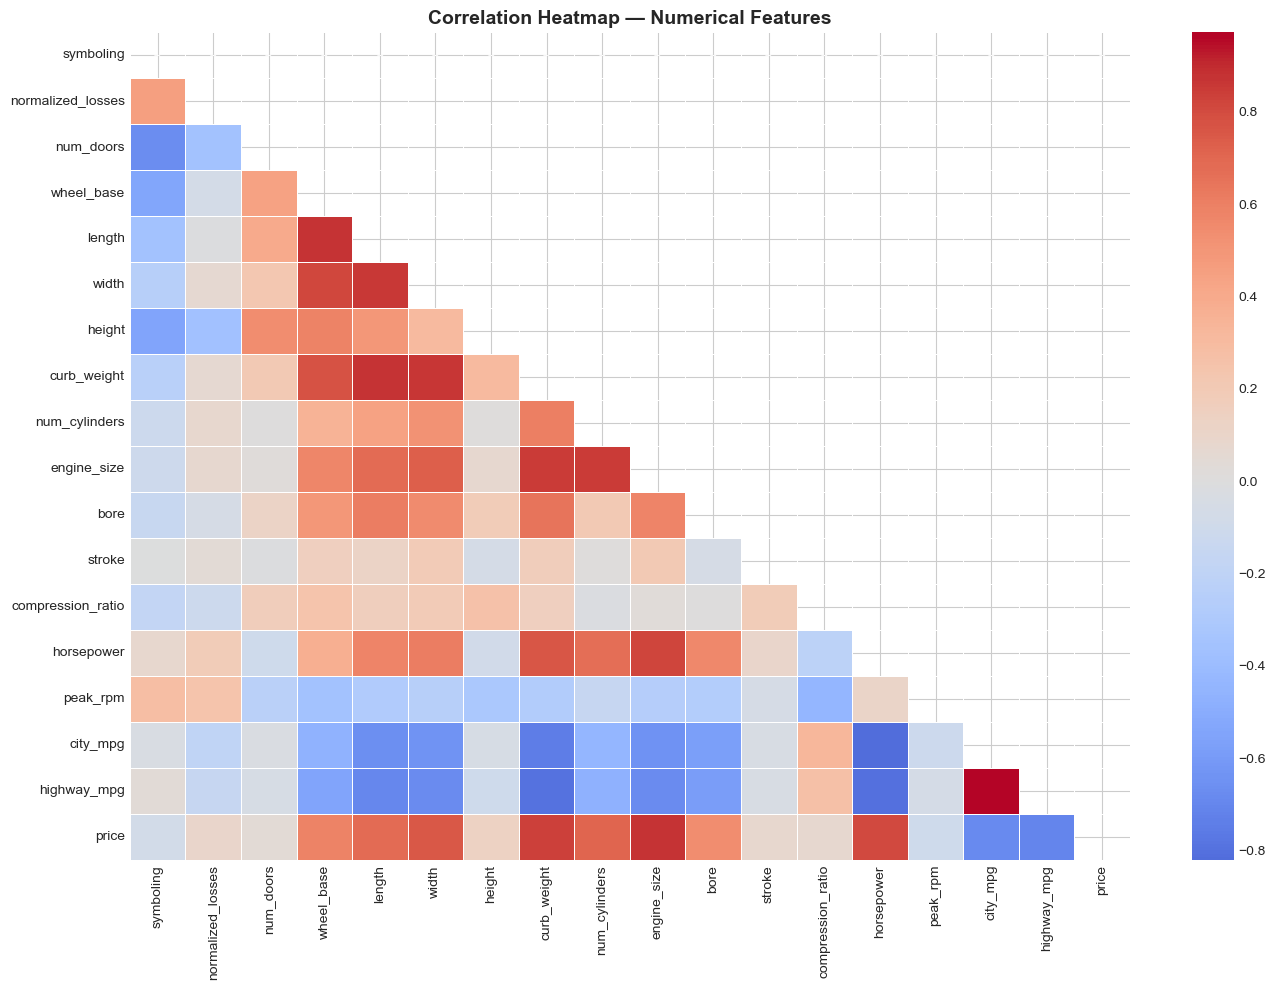

In [24]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

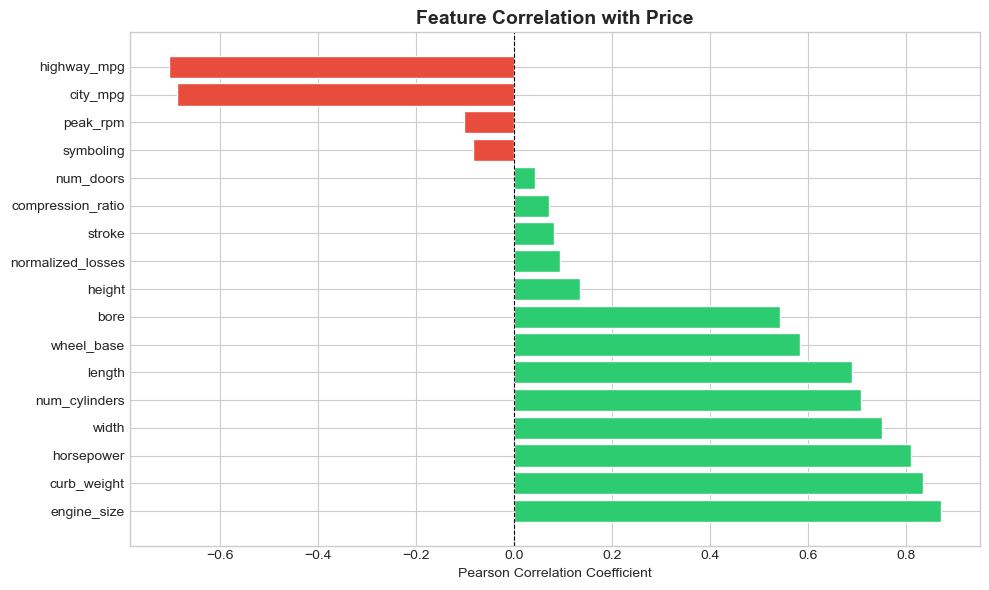

In [25]:
# Top Features correlated with Price
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in price_corr.values]
plt.barh(price_corr.index, price_corr.values, color=colors, edgecolor='white')
plt.title('Feature Correlation with Price', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(output_dir / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

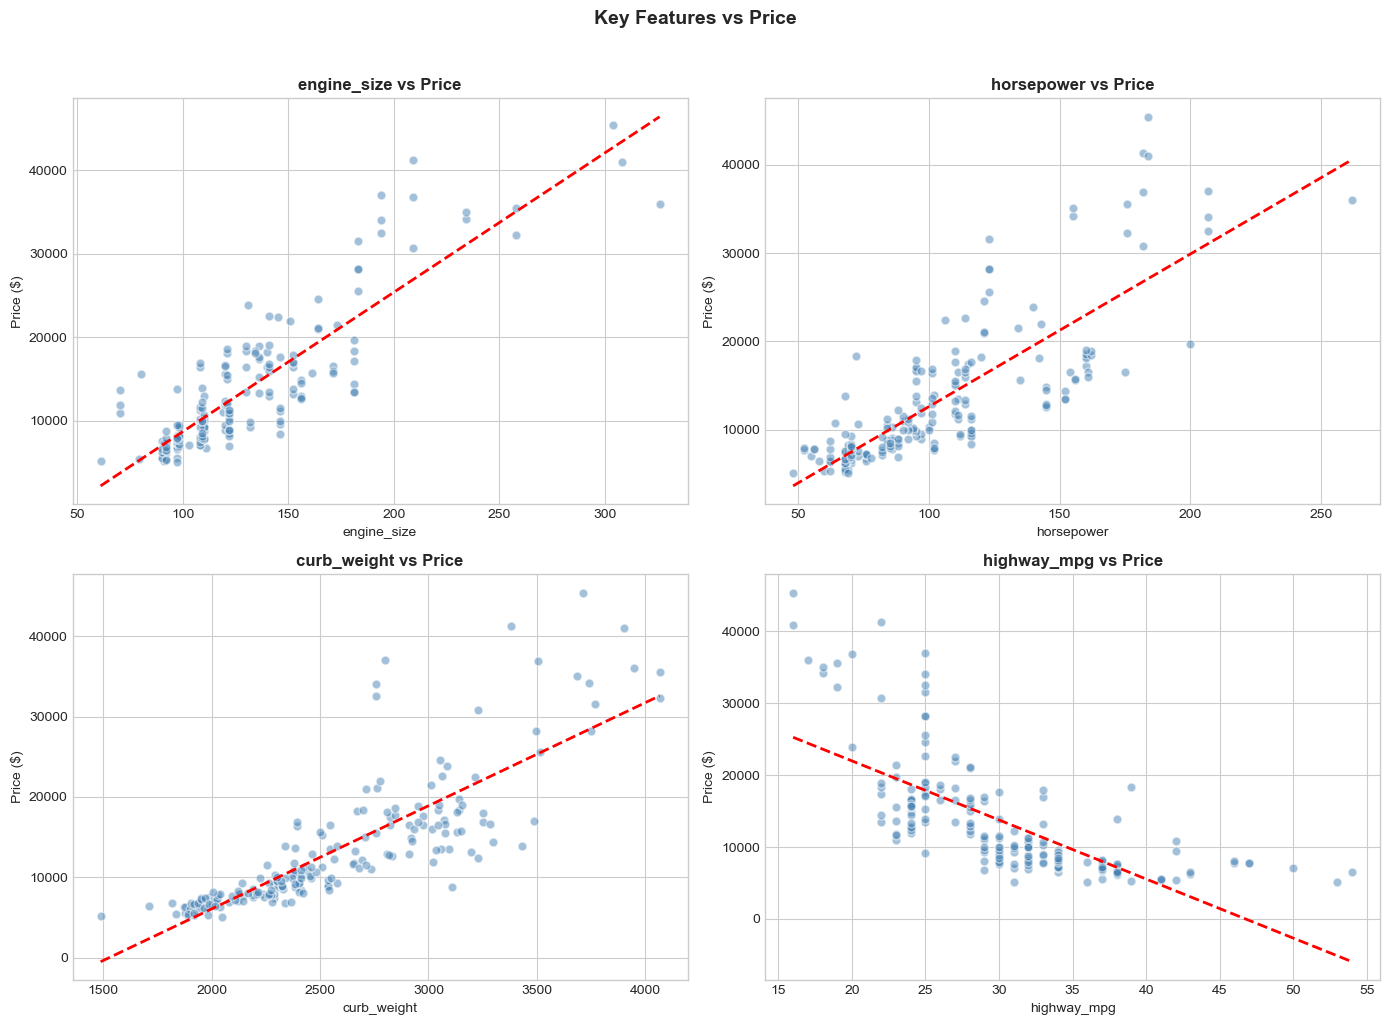

In [22]:
# Scatter plots: Key features vs Price
features_to_plot = ['engine_size', 'horsepower', 'curb_weight', 'highway_mpg']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    axes[i].scatter(df[feat], df['price'], alpha=0.5, color='steelblue', edgecolors='white', s=40)
    # Fit a linear trend only where data is present
    mask = df[feat].notna() & df['price'].notna()
    if mask.sum() > 1:
        z = np.polyfit(df.loc[mask, feat], df.loc[mask, 'price'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df.loc[mask, feat].min(), df.loc[mask, feat].max(), 100)
        axes[i].plot(x_line, p(x_line), 'r--', linewidth=2)
    axes[i].set_title(f'{feat} vs Price', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price ($)')

plt.suptitle('Key Features vs Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_dir / 'scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

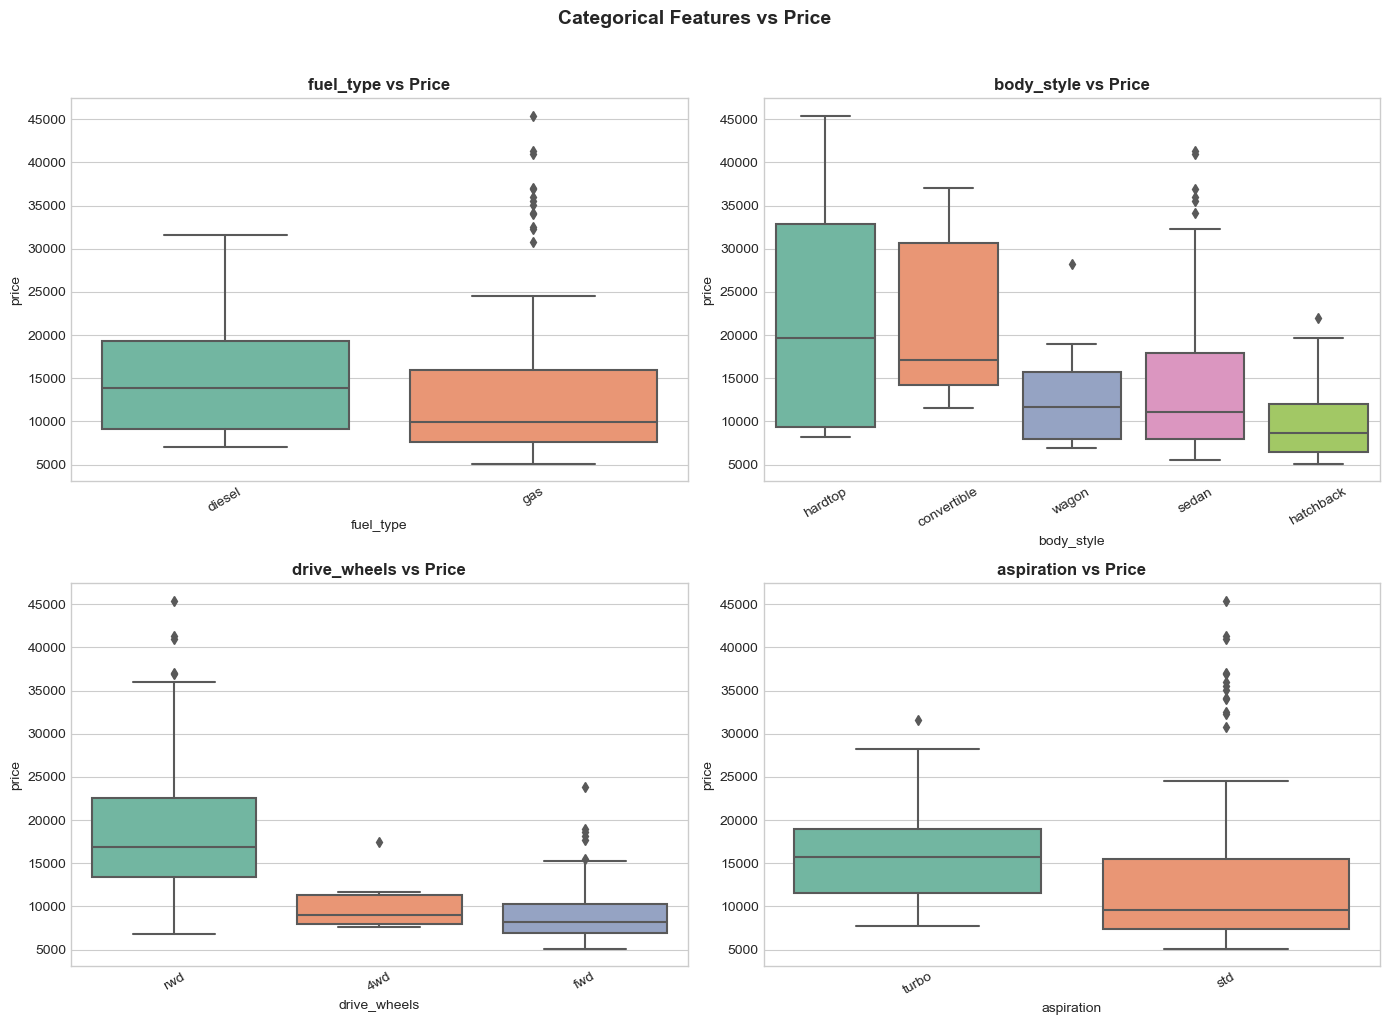

In [26]:
# Box plots for categorical features vs Price
cat_features = ['fuel_type', 'body_style', 'drive_wheels', 'aspiration']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    order = df.groupby(feat)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feat, y='price', order=order, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feat} vs Price', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Features vs Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_dir / 'boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Feature Engineering & Encoding

In [27]:
df_model = df.copy()

# Drop low-value / identifier columns
drop_cols = ['make']  # 'make' has too many categories; drop or encode depending on strategy
# We'll keep make using target encoding concept or simple label encoding

# Identify categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

Categorical columns to encode: ['make', 'fuel_type', 'aspiration', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']


In [28]:
# Label Encoding for ordinal-like categories
# One-Hot Encoding for nominal categories

# High cardinality → Label Encode
label_encode_cols = ['make', 'engine_type', 'fuel_system']
le = LabelEncoder()
for col in label_encode_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Low cardinality → One-Hot Encode
ohe_cols = ['fuel_type', 'aspiration', 'num_doors', 'body_style',
            'drive_wheels', 'engine_location']
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

print(f'Shape after encoding: {df_model.shape}')
print('✅ Encoding complete!')
df_model.head(2)

Shape after encoding: (201, 30)
✅ Encoding complete!


,symboling,normalized_losses,make,wheel_base,length,width,height,curb_weight,engine_type,num_cylinders,...,fuel_type_gas,aspiration_turbo,num_doors_4,body_style_hardtop,body_style_hatchback,body_style_sedan,body_style_wagon,drive_wheels_fwd,drive_wheels_rwd,engine_location_rear
0,3,115.0,0,88.6,168.8,64.1,48.8,2548,0,4,...,True,False,False,False,False,False,False,False,True,False
1,3,115.0,0,88.6,168.8,64.1,48.8,2548,0,4,...,True,False,False,False,False,False,False,False,True,False


In [29]:
# Feature Engineering: Power-to-Weight Ratio
df_model['power_to_weight'] = df_model['horsepower'] / df_model['curb_weight']

# Engine Displacement Proxy
df_model['engine_bore_ratio'] = df_model['engine_size'] / (df_model['bore'] + 1e-5)

# Fuel Efficiency Score
df_model['avg_mpg'] = (df_model['city_mpg'] + df_model['highway_mpg']) / 2

print('✅ Feature engineering done!')
print(f'Total features: {df_model.shape[1] - 1}')  # -1 for price

✅ Feature engineering done!
Total features: 32


---
## Step 6: Train-Test Split & Scaling

In [30]:
# Separate features and target
X = df_model.drop('price', axis=1)
y = df_model['price']

# Handle any remaining NaN after feature engineering
X.fillna(X.median(), inplace=True)

# Ensure all columns are numeric
X = X.select_dtypes(include=[np.number])

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('✅ Scaling done!')

Features shape: (201, 22)
Target shape: (201,)
Train: (160, 22), Test: (41, 22)
✅ Scaling done!


---
## Step 7: Train 8 Regression Models

In [31]:
# Define all models
models = {
    'Linear Regression':      LinearRegression(),
    'Ridge Regression':       Ridge(alpha=1.0),
    'Lasso Regression':       Lasso(alpha=1.0, max_iter=10000),
    'Decision Tree':          DecisionTreeRegressor(random_state=42),
    'Random Forest':          RandomForestRegressor(n_estimators=100, random_state=42),
    'Extra Trees':            ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':                XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Helper: Evaluate a model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    return {
        'Model': name,
        'R2 Score': round(r2, 4),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'CV R2 Mean': round(cv_scores.mean(), 4),
        'CV R2 Std': round(cv_scores.std(), 4)
    }, model, y_pred

results = []
trained_models = {}
predictions = {}

print('Training all models...\n')
for name, model in models.items():
    # Linear models use scaled data; tree-based models use raw
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        result, trained, pred = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)
    else:
        result, trained, pred = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)
    trained_models[name] = trained
    predictions[name] = pred
    print(f'✅ {name}: R²={result["R2 Score"]:.4f}, MAE={result["MAE"]:,.0f}, RMSE={result["RMSE"]:,.0f}')

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
print('\n--- Model Comparison ---')
print(results_df.to_string(index=False))

Training all models...

✅ Linear Regression: R²=0.8399, MAE=3,015, RMSE=4,425
✅ Ridge Regression: R²=0.8152, MAE=3,306, RMSE=4,755
✅ Lasso Regression: R²=0.8386, MAE=3,028, RMSE=4,444
✅ Decision Tree: R²=0.9233, MAE=1,892, RMSE=3,064
✅ Random Forest: R²=0.9311, MAE=1,809, RMSE=2,903
✅ Extra Trees: R²=0.9450, MAE=1,573, RMSE=2,593
✅ Gradient Boosting: R²=0.9512, MAE=1,566, RMSE=2,442
✅ XGBoost: R²=0.9536, MAE=1,449, RMSE=2,382

--- Model Comparison ---
            Model  R2 Score     MAE    RMSE  MAPE (%)  CV R2 Mean  CV R2 Std
          XGBoost    0.9536 1448.57 2381.50      8.41      0.8115     0.0671
Gradient Boosting    0.9512 1565.50 2442.46      9.46      0.8402     0.0561
      Extra Trees    0.9450 1572.74 2593.17      9.09      0.8602     0.0487
    Random Forest    0.9311 1808.74 2902.84      9.75      0.8562     0.0490
    Decision Tree    0.9233 1892.34 3063.99     11.01      0.7846     0.1169
Linear Regression    0.8399 3015.48 4425.40     17.08      0.7932     0.0778
 Lass

---
## Step 8: Model Comparison Visualization

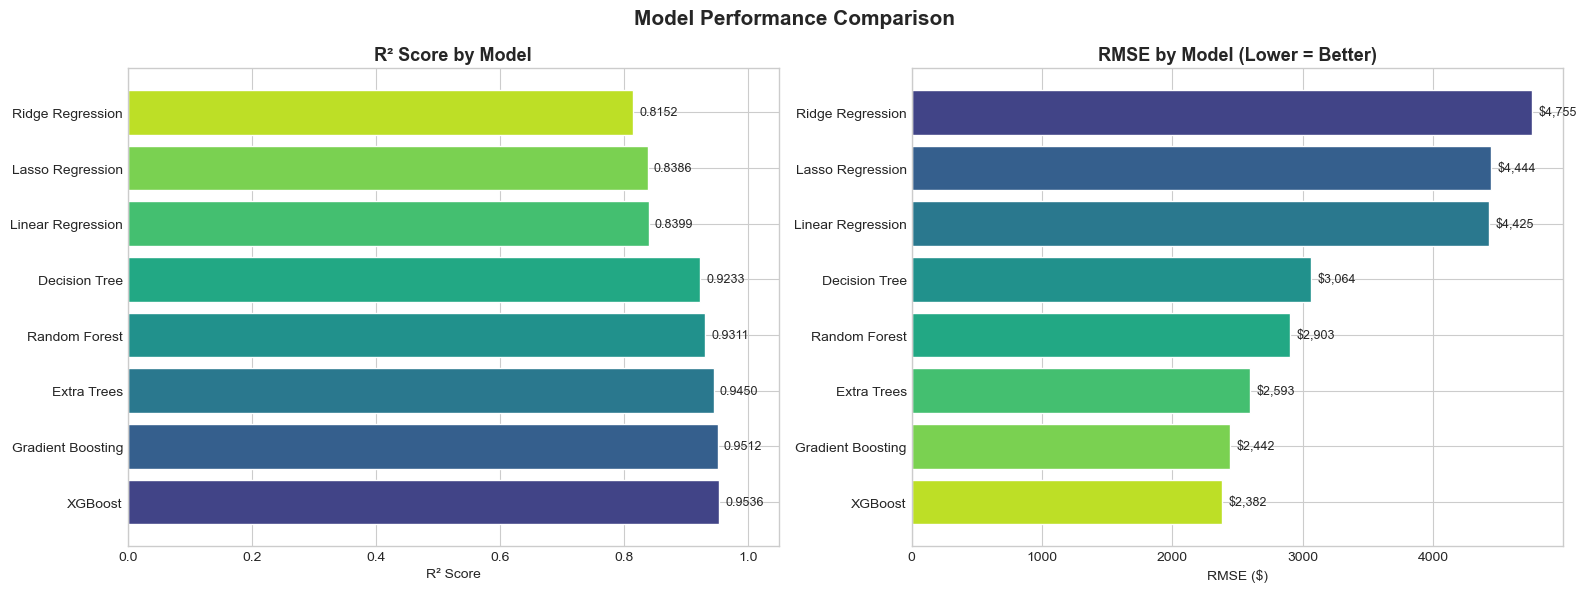

In [32]:
# R² Score Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_df)))

# R2 Score
bars = axes[0].barh(results_df['Model'], results_df['R2 Score'], color=colors, edgecolor='white')
axes[0].set_title('R² Score by Model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, results_df['R2 Score']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# RMSE
bars2 = axes[1].barh(results_df['Model'], results_df['RMSE'], color=colors[::-1], edgecolor='white')
axes[1].set_title('RMSE by Model (Lower = Better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('RMSE ($)')
for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

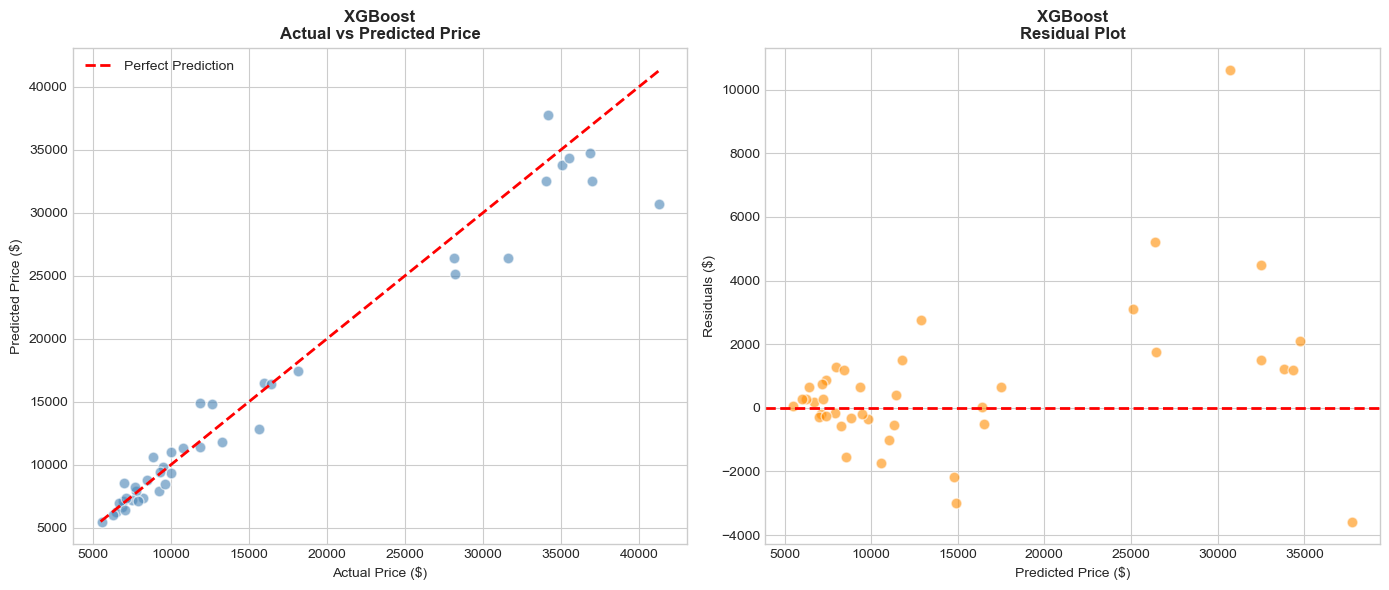

Best Model: XGBoost


In [33]:
# Best model: Actual vs Predicted
best_model_name = results_df.iloc[0]['Model']
best_pred = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.6, color='steelblue', edgecolors='white', s=60)
min_val, max_val = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'{best_model_name}\nActual vs Predicted Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend()

# Residuals
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.6, color='darkorange', edgecolors='white', s=60)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'{best_model_name}\nResidual Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')

plt.tight_layout()
plt.savefig(output_dir / 'best_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Model: {best_model_name}')

---
## Step 9: Feature Importance (Best Model)

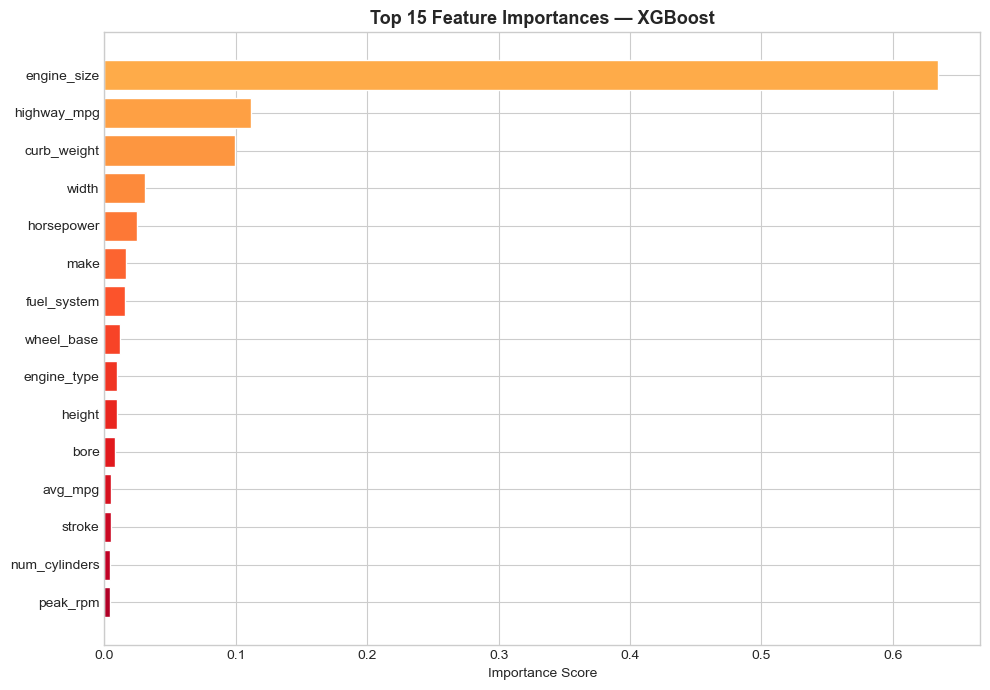

Top 5 important features:
engine_size    0.634620
highway_mpg    0.111181
curb_weight    0.099324
width          0.030813
horsepower     0.025114
dtype: float32


In [34]:
best_model = trained_models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 7))
    colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(feat_imp)))
    plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor='white')
    plt.title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(output_dir / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Top 5 important features:')
    print(feat_imp.head())
else:
    print(f'Feature importance not available for {best_model_name}')

---
## Step 10: Hyperparameter Tuning (Random Forest)

In [35]:
print('Starting GridSearchCV for Random Forest...')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'Best CV R² Score: {grid_search.best_score_:.4f}')

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✅ Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R² Score: 0.8736


In [36]:
# Evaluate tuned model
tuned_rf = grid_search.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test)

r2_tuned   = r2_score(y_test, y_pred_tuned)
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mape_tuned = np.mean(np.abs((y_test - y_pred_tuned) / y_test)) * 100

print('\n📊 Tuned Random Forest Performance:')
print(f'  R²   : {r2_tuned:.4f}')
print(f'  MAE  : ${mae_tuned:,.2f}')
print(f'  RMSE : ${rmse_tuned:,.2f}')
print(f'  MAPE : {mape_tuned:.2f}%')


📊 Tuned Random Forest Performance:
  R²   : 0.8984
  MAE  : $2,146.34
  RMSE : $3,526.10
  MAPE : 10.75%


---
## Step 11: Save Final Model

In [37]:
os.makedirs('../models', exist_ok=True)

# Save the tuned model and scaler
joblib.dump(tuned_rf, '../models/best_automobile_price_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print('✅ Model saved to ../models/best_automobile_price_model.pkl')
print('✅ Scaler saved to ../models/scaler.pkl')
print('✅ Feature names saved to ../models/feature_names.pkl')

✅ Model saved to ../models/best_automobile_price_model.pkl
✅ Scaler saved to ../models/scaler.pkl
✅ Feature names saved to ../models/feature_names.pkl


---
## Step 12: Prediction Function (Inference)

In [38]:
def predict_car_price(input_dict, model_path='../models/best_automobile_price_model.pkl',
                      feature_names_path='../models/feature_names.pkl'):
    """
    Predict car price from a dictionary of features.
    
    Parameters:
    -----------
    input_dict : dict
        Dictionary with feature name -> value pairs
    
    Returns:
    --------
    float : Predicted price in USD
    """
    model = joblib.load(model_path)
    feature_names = joblib.load(feature_names_path)
    
    # Create input DataFrame aligned to training features
    input_df = pd.DataFrame([input_dict])
    input_aligned = input_df.reindex(columns=feature_names, fill_value=0)
    
    predicted_price = model.predict(input_aligned)[0]
    return round(predicted_price, 2)

# Example prediction
sample = X_test.iloc[0].to_dict()
predicted = predict_car_price(sample)
actual = y_test.iloc[0]

print(f'🚗 Sample Prediction:')
print(f'   Actual Price   : ${actual:,.2f}')
print(f'   Predicted Price: ${predicted:,.2f}')
print(f'   Error          : ${abs(actual - predicted):,.2f} ({abs(actual - predicted)/actual*100:.1f}%)')

🚗 Sample Prediction:
   Actual Price   : $8,249.00
   Predicted Price: $7,090.48
   Error          : $1,158.52 (14.0%)


---
## Step 13: Final Summary

In [39]:
print('='*60)
print('  AUTOMOBILE PRICE PREDICTION — PROJECT SUMMARY')
print('='*60)
print(f'\n📁 Dataset     : UCI Automobile Dataset (1985)')
print(f'📊 Samples     : {df.shape[0]} cars, {X.shape[1]} features')
print(f'🧩 Models Tried: 8 Regression Algorithms')
print(f'\n🏆 Best Model  : Tuned Random Forest')
print(f'   R² Score    : {r2_tuned:.4f} ({r2_tuned*100:.1f}% variance explained)')
print(f'   MAE         : ${mae_tuned:,.2f}')
print(f'   RMSE        : ${rmse_tuned:,.2f}')
print(f'   MAPE        : {mape_tuned:.2f}%')
print(f'\n📌 Top Features: engine_size, curb_weight, horsepower')
print(f'💾 Model saved to: models/best_automobile_price_model.pkl')
print('='*60)

  AUTOMOBILE PRICE PREDICTION — PROJECT SUMMARY

📁 Dataset     : UCI Automobile Dataset (1985)
📊 Samples     : 201 cars, 22 features
🧩 Models Tried: 8 Regression Algorithms

🏆 Best Model  : Tuned Random Forest
   R² Score    : 0.8984 (89.8% variance explained)
   MAE         : $2,146.34
   RMSE        : $3,526.10
   MAPE        : 10.75%

📌 Top Features: engine_size, curb_weight, horsepower
💾 Model saved to: models/best_automobile_price_model.pkl
